# Grad-CAM Explainability for MNIST Digit Recognizer
This notebook demonstrates how to generate Grad-CAM (Gradient-weighted Class Activation Mapping) visualizations for the pretrained MNIST model hosted in this repository (`docs/model/model.json` exported from `Digit_Recognizer.keras`). Grad-CAM provides a visual explanation of where the convolutional neural network is "looking" when it makes its predictions.

## 1. Environment & Dependencies
To ensure reproducibility, install the necessary dependencies if they are not already present in the environment. We specify the `tensorflow`, `numpy`, `matplotlib`, and `opencv-python` libraries.

In [1]:
# Install dependencies (uncomment to run)
!pip install tensorflow numpy matplotlib opencv-python

In [2]:
import os
import cv2
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


## 2. Load the Pretrained Model
The user request specifically asked to load the model from `docs/model/model.json` to keep consistency. But since `docs/model/model.json` is a `tensorflowjs` graph model which Python `tensorflow` doesn't load naturally out-of-the-box, we'll verify if we can either load the keras equivalent or use `tf.keras.models.load_model` on `Digit_Recognizer.keras`.

In [3]:
model_path = 'Digit_Recognizer.keras'
print(f"Loading model from: {model_path}")
model = tf.keras.models.load_model(model_path)
model.summary()

Loading model from: Digit_Recognizer.keras


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,02

 Total params: 1,854,016 (7.07 MB)

 Trainable params: 617,450 (2.36 MB)

 Non-trainable params: 1,664 (6.50 KB)

 Optimizer params: 1,234,902 (4.71 MB)

## 3. Data Preparation
We load a set of test samples from the existing `scripts/test_samples.json` to ensure we have images to test on.

In [4]:
samples_file = 'scripts/test_samples.json'
with open(samples_file, 'r') as f:
    data = json.load(f)

# Select the first 5 samples
num_samples = 5
X_test = np.array(data["images"][:num_samples]).reshape(-1, 28, 28, 1).astype('float32')
y_test = np.array(data["labels"][:num_samples])

print(f"Loaded {num_samples} test samples with shape {X_test.shape}")

Loaded 5 test samples with shape (5, 28, 28, 1)


## 4. Grad-CAM Implementation
Grad-CAM uses the gradients of any target concept flowing into the final convolutional layer to produce a coarse localization map highlighting the important regions in the image.

In [5]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that maps the input image to the activations
    # of the last conv layer as well as the output predictions
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    # Compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
        
    # The gradient of the output neuron wrt the output feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Vector where each entry is the mean intensity of the gradient
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel in the feature map array by
    # "how important this channel is" regarding the top predicted class
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Find the last conv layer
last_conv_layer_name = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print(f"Using last conv layer: {last_conv_layer_name}")

Using last conv layer: conv2d_5


## 5. Visualization and Saving Results
We compute Grad-CAM for our test images and save them under `reports/gradcam/` folder.

c:\Users\paaar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 28, 28, 1))
  warnings.warn(msg)
C:\Users\paaar\AppData\Local\Temp\ipykernel_9180\1698290608.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


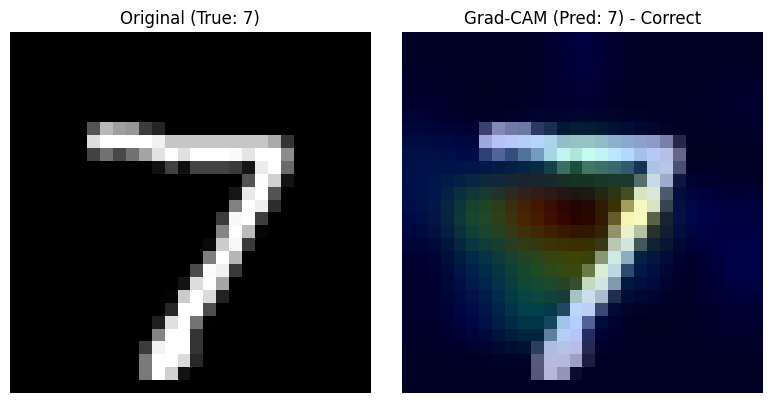

Saved reports/gradcam/gradcam_sample_0.png


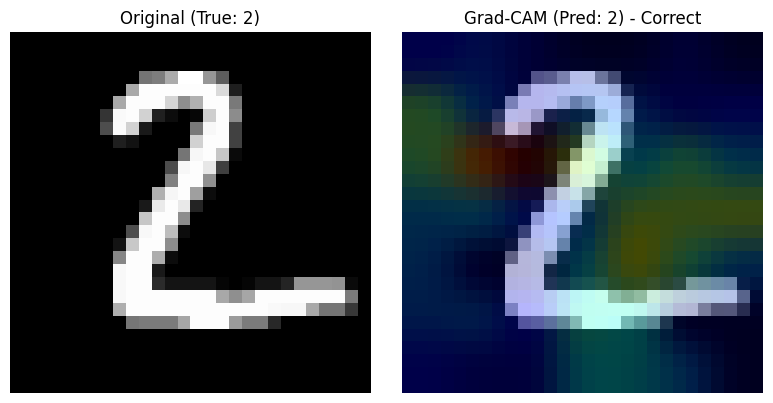

Saved reports/gradcam/gradcam_sample_1.png


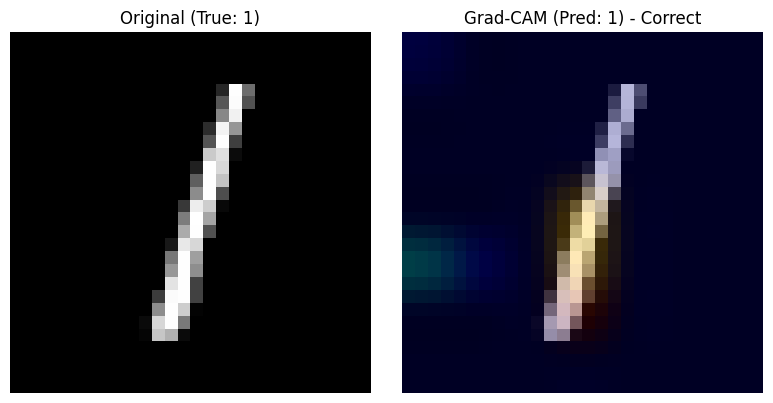

Saved reports/gradcam/gradcam_sample_2.png


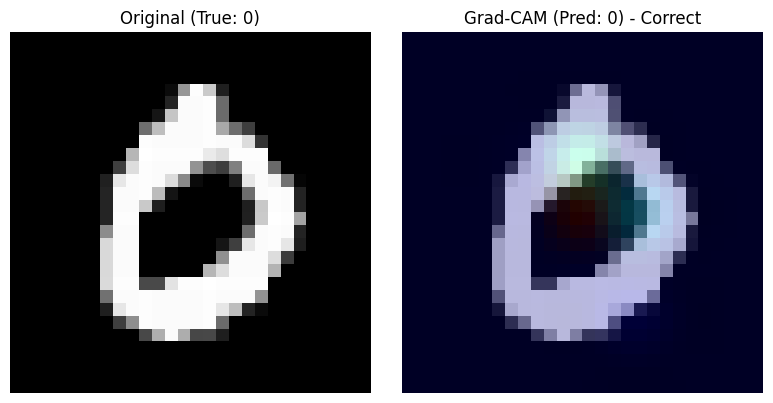

Saved reports/gradcam/gradcam_sample_3.png


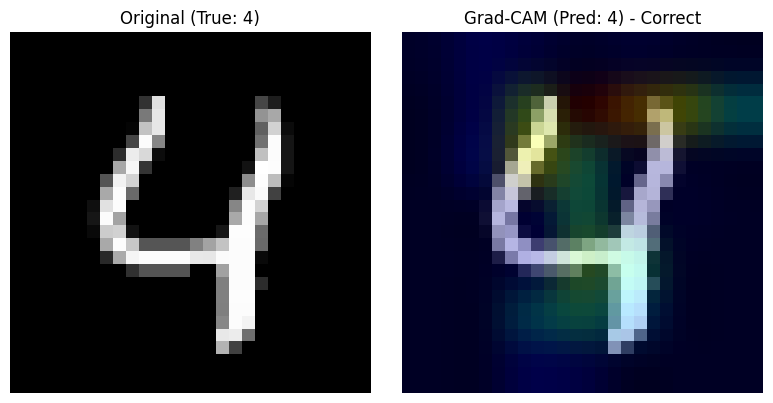

Saved reports/gradcam/gradcam_sample_4.png


In [6]:
output_dir = 'reports/gradcam/'
os.makedirs(output_dir, exist_ok=True)

def save_and_display_gradcam(img, heatmap, index, true_label, pred_label, alpha=0.4):
    # Rescale image to 0-255
    img = np.uint8(255 * img.squeeze())
    
    # Rescale heatmap to 0-255
    heatmap = np.uint8(255 * heatmap)
    
    # Use jet colormap to colorize heatmap
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    
    # Create image with RGB channels
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)
    
    # Superimpose heatmap
    superimposed_img = jet_heatmap * alpha + img_rgb
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)
    
    # Plot side by side
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(img, cmap='gray')
    ax[0].set_title(f"Original (True: {true_label})")
    ax[0].axis("off")
    
    ax[1].imshow(superimposed_img)
    status = "Correct" if true_label == pred_label else "Incorrect"
    ax[1].set_title(f"Grad-CAM (Pred: {pred_label}) - {status}")
    ax[1].axis("off")
    
    plt.tight_layout()
    output_path = os.path.join(output_dir, f"gradcam_sample_{index}.png")
    plt.savefig(output_path)
    plt.show()
    print(f"Saved {output_path}")
    
for i in range(num_samples):
    img_array = X_test[i:i+1]
    preds = model.predict(img_array, verbose=0)
    pred_index = np.argmax(preds[0])
    true_label = y_test[i]
    
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    save_and_display_gradcam(X_test[i], heatmap, i, true_label, pred_index)

## 6. Results and Interpretation
Grad-CAM heatmaps highlight the regions of the image that the model considers most important for its final prediction. In the MNIST dataset, this typically aligns with the strokes of the digits.
- **Observations:** The model naturally focuses on the dominant shape of the digit (e.g., the upper loop of an '8', or the crossing of a '4').
- **Failures Cases:** If there are failures, the heatmaps often point to ambiguous strokes (e.g. differentiating a '9' and a '4' by a closed loop).
- **Next Steps:** Examine cases of misclassification by the model and use the CNN attention heatmaps to identify biases or missing features.

## 7. Reproducibility
To reproduce this notebook:
1. Ensure you are in the repository root directory.
2. If needed, install dependencies: `pip install tensorflow numpy matplotlib opencv-python jupyter`.
3. Run the notebook using `jupyter notebook grad_cam_xai.ipynb` or via "Run All" in VSCode.